# Assignment-2 COMP-5970 Jacob Murrah
## README
This assignment builds on your understanding of geometric transformations
and introduces you to real-world applications of feature matching and
homography. You will use concepts from Lecture 6 and beyond, such as
keypoint detection, perspective transformations, and image warping, to solve
a visual puzzle automatically. This is where geometry meets computer vision
magic!

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **opencv-python**
- **ipython**
- **scikit-image**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
GenAI was used to explain the basics of SIFT, FLANN, Lowe's Ratio Test, RANSAC, keypoint detection, and homography.

## Statement of Contribution
This was an individual project and I did everything in it.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

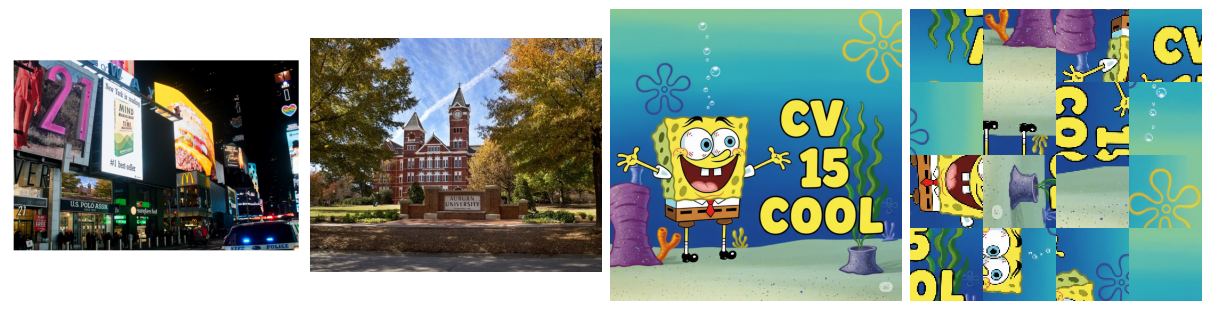

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io
from skimage import color as change
import cv2
from IPython.display import Image
import math


# Loading images
np.set_printoptions(precision=2)

scene = cv2.cvtColor(
    cv2.imread('Part1_scene.png'), cv2.COLOR_BGR2RGB
)
auburn = cv2.cvtColor(
    cv2.imread('auburn.jpeg'), cv2.COLOR_BGR2RGB
)
puzzle_ref = cv2.cvtColor(
    cv2.imread('puzzle_reference.png'), cv2.COLOR_BGR2RGB
)
puzzle_scr = cv2.cvtColor(
    cv2.imread('puzzle_scrambled.png'), cv2.COLOR_BGR2RGB
)


fig, axes = plt.subplots(1, 4, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(scene)
axes[0].axis('off')
axes[1].imshow(auburn)
axes[1].axis('off')
axes[2].imshow(puzzle_ref)
axes[2].axis('off')
axes[3].imshow(puzzle_scr)
axes[3].axis('off')

# PART 1) Localize a Hidden Object in the Scene
Your goal is to automatically find a hidden object (e.g., an image of Samford
Hall) in a real-world scene using feature matching. Then, using geometric
reasoning, you will highlight where the object appears in the scene.

## Description of Approach
I know that Samford Hall is hidden in the scene. If I can find the features of Samford Hall there should be an area in the scene that matches those same features. I know I can use SIFT to get the features of both Samford Hall and the scene. In order to obtain matching features I can use FLANN and the Lowe's ratio test to get all of the good feature matches between the scene and Samford Hall. Once I have the good features I can use RANSAC to map the features of Samford Hall to their location in the scene and finally perform a perspective transform to create a bounding box that borders Samford Hall.

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
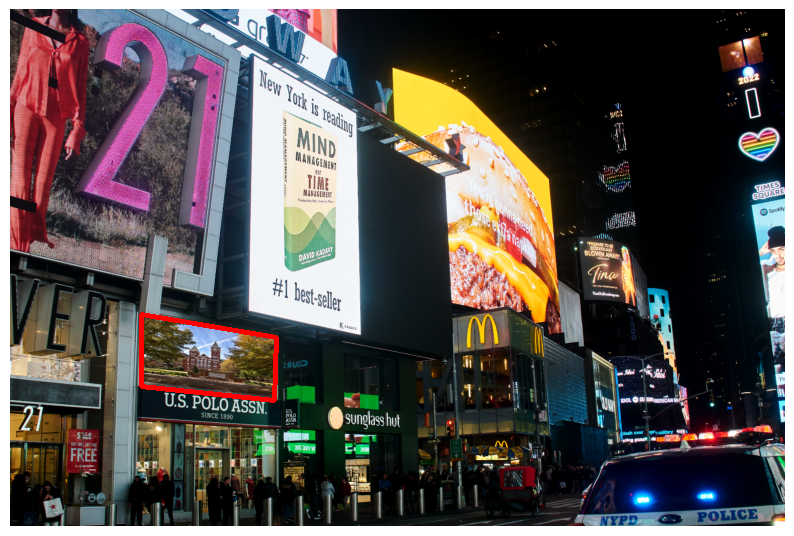

In [8]:
scene_gray = cv2.cvtColor(scene, cv2.COLOR_RGB2GRAY)
auburn_gray = cv2.cvtColor(auburn, cv2.COLOR_RGB2GRAY)

# SIFT
sift = cv2.SIFT_create()
kp_scene, des_scene = sift.detectAndCompute(scene_gray, None)
kp_auburn, des_auburn = sift.detectAndCompute(auburn_gray, None)

# FLANN
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des_scene, des_auburn, k=2)

# Lowe's ratio test
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

# RANSAC
src_pts = np.float32(
    [kp_scene[m.queryIdx].pt for m in good_matches]
).reshape(-1, 1, 2)
dst_pts = np.float32(
    [kp_auburn[m.trainIdx].pt for m in good_matches]
).reshape(-1, 1, 2)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
height, width = scene.shape[:2]
warped_img = cv2.warpPerspective(auburn, H, (width, height))

# Perspective transform
auburn_h, auburn_w = auburn.shape[:2]
auburn_corners = np.float32(
    [
        [0, 0],
        [auburn_w - 1, 0],
        [auburn_w - 1, auburn_h - 1],
        [0, auburn_h - 1]
    ]
).reshape(-1, 1, 2)
projected_corners = cv2.perspectiveTransform(auburn_corners, H)
cv2.polylines(
    scene.copy(),
    [np.int32(projected_corners)],
    True,
    (255, 0, 0), # NOTE: Bounding box is in RED!
    3
)

The bounding box around Samford hall is in RED!

# PART 2) Geometric Puzzle Solver v2
In the previous assignment, you manually tested combinations of
transformations (rotation, flipping) to piece together the correct image. This
time, you will automatically identify the correct orientation and location of
each tile by matching it to the original image using SIFT features and
homography.

## Description of Approach
I know the scrambled image is split into 16 tiles that are 64x64 pixels and that when reconstructed they should look like the reference image. My approach is to use SIFT to match the features of each individual tile to the reference image. Similar to part 1, I then use FLANN and the Lowe's ratio test to get all of the good feature matches between the reference image and each tile. Finally I can use RANSAC to map the features of each tile to their location in the reference image and perform a homography to place the tile into the output image.

NOTES:
- For each tile i check the horizontal and vertical flips and only keep the flip with the most inliers since SIFT is NOT flip-invariant.
- I tuned the hyperparameters of both SIFT and FLANN to look for smaller features since the tiles are so small and there are a lot of similarities in each tile.

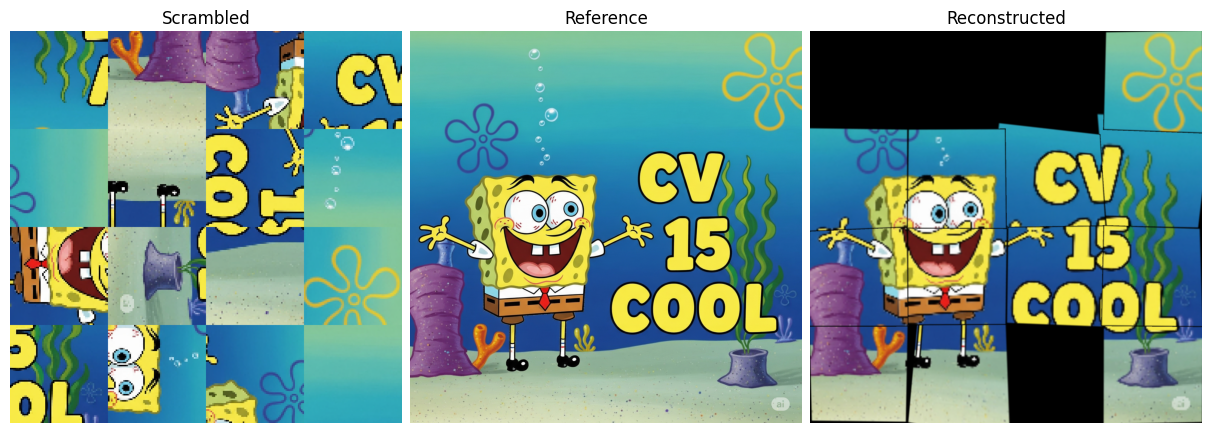

In [15]:
# SIFT
SIFT = cv2.SIFT_create(
    nfeatures=0,
    nOctaveLayers=6,
    contrastThreshold=0.01,
    edgeThreshold=100,
    sigma=1.6
)

def get_homography_H(kp_src, des_src, kp_dest, des_dest):
    # FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=200)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des_src, des_dest, k=2)

    # Lowe's ratio test
    good_matches = [m for m, n in matches if m.distance < 0.8 * n.distance]
    if len(good_matches) < 4:
        return None, None

    # RANSAC
    src_pts = np.float32(
        [kp_src[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [kp_dest[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if H is None:
        return None, None

    mask = mask.ravel()
    inliers = int(np.count_nonzero(mask))

    return H, inliers


output = np.zeros_like(puzzle_ref)
ref_gray = cv2.cvtColor(puzzle_ref, cv2.COLOR_RGB2GRAY)
kp_ref, des_ref = SIFT.detectAndCompute(ref_gray, None)

placed_mask = np.zeros((puzzle_ref.shape[0], puzzle_ref.shape[1]), dtype=bool)
for i, tile_row_start in enumerate(range(0, 256, 64)):
    for j, tile_col_start in enumerate(range(0, 256, 64)):
        tile_scr = puzzle_scr[
            tile_row_start:tile_row_start+64,
            tile_col_start:tile_col_start+64,
            :
        ]

        # NOTE: SIFT is NOT flip-invariant
        variants = [
            tile_scr,
            cv2.flip(tile_scr, 0),
            cv2.flip(tile_scr, 1),
            cv2.flip(tile_scr, -1),
        ]

        best_variant = None
        for tile_var in variants:
            scr_gray = cv2.cvtColor(tile_var, cv2.COLOR_RGB2GRAY)
            kp_scr, des_scr = SIFT.detectAndCompute(scr_gray, None)
            if des_scr is None or len(kp_scr) < 4:
                continue

            H, inliers = get_homography_H(kp_scr, des_scr, kp_ref, des_ref)
            if H is None:
                continue

            if best_variant is None or inliers > best_variant[1]:
                best_variant = (H, inliers, tile_var)

        if best_variant is None:
            continue

        H, inliers, tile_var = best_variant
        warped = cv2.warpPerspective(
            tile_var,
            H,
            (output.shape[1], output.shape[0])
        )
        mask = np.any(warped != 0, axis=2)

        output[mask] = warped[mask]
        placed_mask |= mask

fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(puzzle_scr)
axes[0].set_title("Scrambled")
axes[0].axis('off')
axes[1].imshow(puzzle_ref)
axes[1].set_title("Reference")
axes[1].axis('off')
axes[2].imshow(output)
axes[2].set_title("Reconstructed")
axes[2].axis('off')
plt.show()